# Маркетинговое исследование

**Цель исследования:** Оценить эффективность внедрения изменений (treatment) на основе собранных данных, проверить наличие смещений, проконтролировать защитные метрики и сделать итоговый вывод о продуктовом эффекте.

**Описание данных:** 
В распоряжении имеется датасет, содержащий следующие ключевые колонки:  
`user_id` — уникальный идентификатор пользователя;  
`test_group` — флаг принадлежности к группе (контроль / тест);  
`converted` — целевая метрика конверсии (бинарный признак целевого действия);  
`total_ads` — совокупное количество показанной рекламы;  
`most_ads_day` — день недели с максимальной активностью показов рекламы;  
`most_ads_hour` — час суток с наибольшим количеством показов.

**План анализа:** 
1. Первичный EDA-анализ
2. Проверка рандомизации
3. Дизайн статистического эксперимента и результаты
4. Применение метода CUPED для снижения дисперсии
5. Контроль защитных метрик (Guardrail Metrics)
6. Финальная оценка бизнес-эффекта и принятие решения

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv("marketing_AB.csv", index_col=0)

In [3]:
df.head(5)

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


## 1. Первичный EDA - анализ

#### Качество данных:
* Отсутствуют пропуски
* Правильные типы данных

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 27.5+ MB


#### Распределение тестовой и контрольной группы
Наблюдаем сильный дисбаланс классов контрольной и тестовой групп:  **4%** против **96%**

In [5]:
df['test group'].value_counts(normalize=True)

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64

#### Распределение данных
* `most ads hour` - распределен нормально
* `most ads day` - распределен равномерно
* `total ads` - скошенное вправо распределение, много выбросов

In [6]:
df.iloc[:, 1:].describe()

,total ads,most ads hour
count,588101.000000,588101.000000
mean,24.820876,14.469061
std,43.715181,4.834634
min,1.000000,0.000000
25%,4.000000,11.000000
50%,13.000000,14.000000
75%,27.000000,18.000000
max,2065.000000,23.000000


<Axes: xlabel='most ads hour', ylabel='Density'>

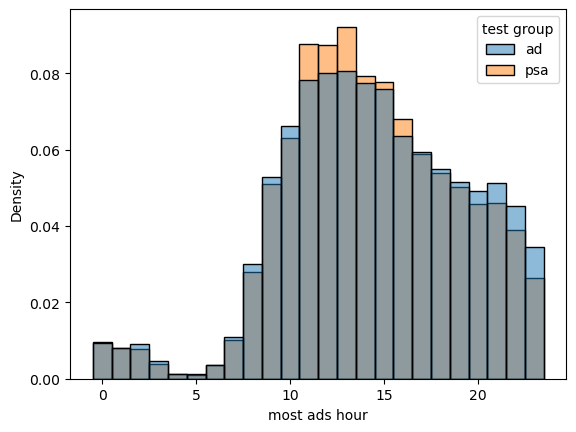

In [7]:
sns.histplot(data=df, x='most ads hour', hue='test group', discrete=True, common_norm=False, stat='density')

<Axes: xlabel='most ads day', ylabel='Density'>

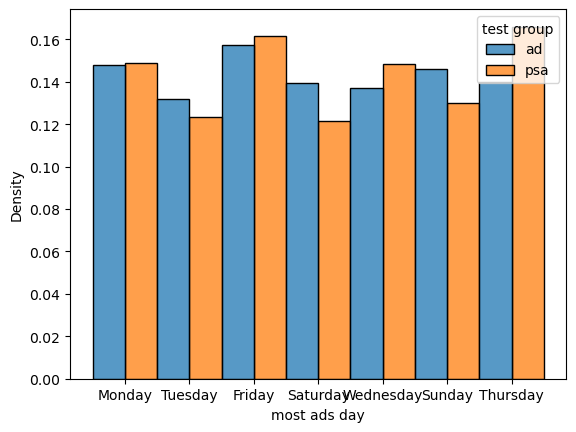

In [8]:
sns.histplot(data=df, x='most ads day', hue='test group', discrete=True, stat='density', common_norm=False, multiple='dodge')

<Axes: xlabel='total ads', ylabel='Density'>

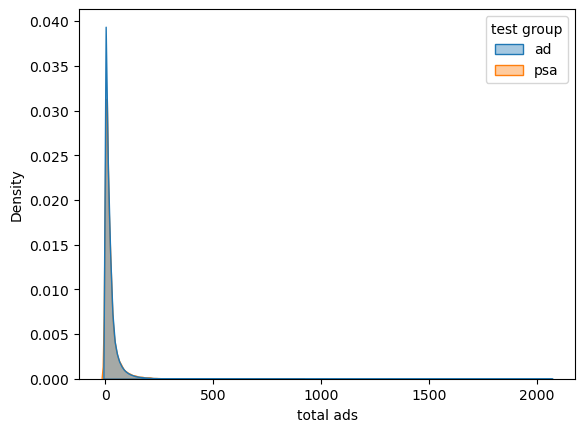

In [9]:
sns.kdeplot(data=df, x='total ads', hue='test group',fill=True, alpha=0.4, common_norm=False)

<Axes: xlabel='total ads'>

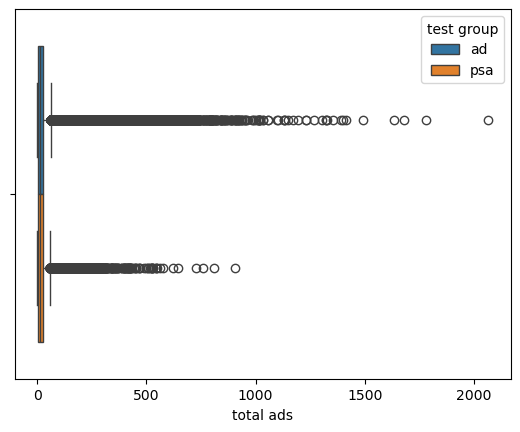

In [10]:
sns.boxplot(df, x='total ads', hue='test group')

<Axes: xlabel='total ads', ylabel='Density'>

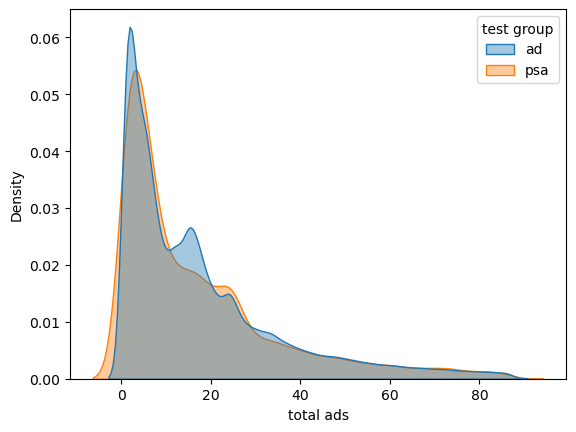

In [11]:
q_95 = df['total ads'].quantile(0.95)
sns.kdeplot(data=df[df['total ads'] < q_95], x='total ads', hue='test group',fill=True, alpha=0.4, common_norm=False)

### Основная статистика данных

In [12]:
control = df[df['test group'] == 'psa']
treatment = df[df['test group'] == 'ad']

conversion_control = control['converted'].mean()
conversion_treatment = treatment['converted'].mean()

n_control = len(control)
n_treatment = len(treatment)

In [13]:
print("Количество наблюдений: ", len(df))
print("Количество наблюдений в контрольной группе: ", n_control)
print("Количество наблюдений в тестовой группе: ", n_treatment)
print("Конверсия в контрольной группе: ", conversion_control)
print("Конверсия в тестовой группе: ", conversion_treatment)
print(f'Наблюдаемый эффект: {conversion_treatment/conversion_control - 1:.2%}')

Количество наблюдений:  588101
Количество наблюдений в контрольной группе:  23524
Количество наблюдений в тестовой группе:  564577
Конверсия в контрольной группе:  0.01785410644448223
Конверсия в тестовой группе:  0.025546559636683747
Наблюдаемый эффект: 43.09%


## 2. Проверка сопоставимости групп
**Контекст данных:** Поскольку это не классический рандомизированный A/B тест, а скорее анализ наблюдательных данных, существовует риск искажения результатов из-за разницы в исходном составе групп.  
**Что смотрим:** Оценим линейные и нелинейные зависимости между исходными признаками и фактом попадания в тестовую группу.
* **Если связь слабая (близка к нулю):** распределение близко к случайному, группы сбалансированы почти как в честном A/B-тесте, а прямое сравнение корректно.  
* **Если связь сильная:** выраженный системный перекос, из-за которого прямое сравнение даст искаженный результат. Позволяет заранее увидеть масштаб проблемы и оценить необходимость методов балансировки (например, Propensity Score).

#### Поиск линейной связи признаков с принадлежностью к тестовой группе - `treatment`

In [14]:
df['treatment'] = df['test group'] == 'ad'

,converted,total ads,most ads hour,treatment
converted,1.000000,0.217419,0.019674,0.009611
total ads,0.217419,1.000000,-0.010837,0.000279
most ads hour,0.019674,-0.010837,1.000000,0.006930
treatment,0.009611,0.000279,0.006930,1.000000


<Axes: >

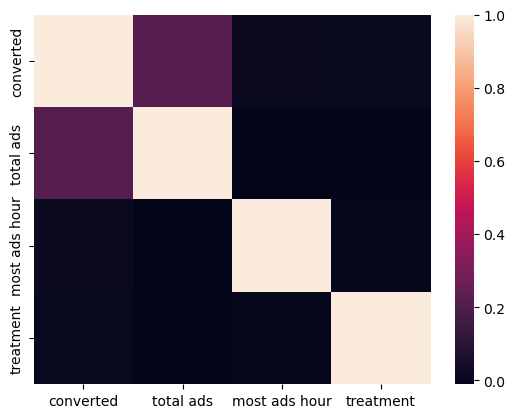

In [15]:
corr = df.iloc[:, 1:].corr(numeric_only=True)
display(corr)
sns.heatmap(corr)

#### Поиск нелинейной связи признаков с принадлежностью к тестовой группе - `treatment`

In [16]:
from sklearn.feature_selection import mutual_info_classif

X_mi = df[['total ads', 'most ads hour']].copy()
X_mi['most ads day'] = pd.Categorical(df['most ads day']).codes

mi_scores = mutual_info_classif(
    X_mi, 
    df['treatment'], 
    discrete_features=[False, False, True],
    random_state=42
)

for col, score in zip(X_mi.columns, mi_scores):
    print(f"Мера взаимной информации с 'treatment' для {col}: {score:.4f}")

Мера взаимной информации с 'treatment' для total ads: 0.0010
Мера взаимной информации с 'treatment' для most ads hour: 0.0077
Мера взаимной информации с 'treatment' для most ads day: 0.0002


---
**Анализ независимости признаков и Treatment**  

Для проверки наличия линейных и нелинейных связей между ковариатами `total ads`, `most ads hour`, `most ads day` и фактором воздействия `treatment` был применен метод оценки взаимной информации (Mutual Information).  
Полученные показатели близки к нулю (в диапазоне от $0.0002$ до $0.0077$), что подтверждает отсутствие линейной или нелинейной зависимости между признаками пользователей и их распределением по группам.  

*P.s. визуальная схожесть распределений из пункта "1. EDA-анализ" дополнительно подтверждает вывод выше*

*Вывод:*  
Таким образом, несмотря на дисбаланс размеров групп, по имеющимся характеристикам выборки распределены случайно и независимо (отсутствует смещение выборки). В связи с этим применение моделей Propensity Score и весовых коэффициентов не требуется. 

## 3. Статистический дизайн эксперимента
**Тип теста:**   
Односторонний z-тест для пропорций:  
* Целевая метрика бинарна (конверсия)
* Большой объем выборки обеспечивает нормальную аппроксимацию выборочного распределения пропорции (ЦПТ)
* Направление эффекта задано априорно: тестируется только рост метрики

**Гипотезы:**  
${H_0}$: Конверсия тестовой группы не превышает конверсию контрольной группы  
${H_1}$: Конверсия тестовой группы превышает конверсию контрольной

**Параметры:**  
Уровень значимости ${\alpha}$ = 0.05  
Мощность ${power}$ = 0.80  
Минимальный эффект ${MDE}$ = +2 п.п.

In [17]:
alpha = 0.05
power = 0.8
mde = 0.02 # в процентах

In [18]:
def cohen_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p2)) - np.arcsin(np.sqrt(p1)))

def required_sample_size(p_base: float, mde: float, alpha: float = 0.05, power: float = 0.8, two_sided = False):
    p_expect = p_base * (1 + mde)
    effect_size = cohen_h(p_base, p_expect)
    
    n_per_group = zt_ind_solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        alternative='two-sided' if two_sided else 'larger',
    )

    return int(np.ceil(n_per_group))

In [19]:
sample_size = required_sample_size(conversion_control, 0.2)
print("Минимальный размер выборки в каждой группе: ", sample_size)

Минимальный размер выборки в каждой группе:  18634


In [20]:
x_control = control['converted'].sum()
x_treatment = treatment['converted'].sum()

counts = np.array([control['converted'].sum(), treatment['converted'].sum()])
nobs = np.array([n_control, n_treatment])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='smaller')

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Z-статистика: -7.3701
p-value: 0.0000


**Вывод:**  
Таким образом получены статистически значимые различия между тестовой и контрольной группами.  
Следовательно можно отвергнуть нулевую гипотезу на заданном уровне статистической значимости ${\alpha}$ = 0.05 

## 4. Применение метода CUPED для снижения дисперсии
На этапе проверки рандомизации групп (пункт 2) была зафиксирована слабая корреляционная связь целевой переменной с одной из ковариат.   

**Что пробуем:** Несмотря на слабую связь, применим метод CUPED, чтобы попытаться скорректировать целевую метрику по историческим данным.   
**Зачем это нужно:** Даже при невысокой корреляции CUPED теоретически способен снизить дисперсию метрики и повысить статистическую мощность теста. Так эмпирически проверим, даст ли этот метод ощутимый выигрыш в точности на данных или эффект от слабой связи окажется пренебрежимо мал.  
**Что делаем:** Рассчитываем скорректированную целевую переменную с учетом ковариаты и оцениваем степень уменьшения дисперсии по сравнению с «сырыми» данными.

In [21]:
def cuped_adjustment(y: np.ndarray, x: np.ndarray, theta: float):
    return y - theta * (x - x.mean())

def cuped_ab_test(y_control: np.ndarray, y_treatment: np.ndarray, x_control: np.ndarray, x_treatment: np.ndarray, alpha: float = 0.05):
    y_all = np.concatenate([y_control, y_treatment])
    x_all = np.concatenate([x_control, x_treatment])
    correlation = np.corrcoef(y_all, x_all)[0, 1]

    theta = np.cov(y_control, x_control, ddof=1)[0, 1] / x_control.var(ddof=1)

    y_control_adj = cuped_adjustment(y_control, x_control, theta=theta)
    y_treatment_adj = cuped_adjustment(y_treatment, x_treatment, theta=theta)
    
    # analysis
    effect_raw = y_treatment.mean() - y_control.mean()
    se_raw = np.sqrt(y_control.var(ddof=1)/len(y_control) + y_treatment.var(ddof=1)/len(y_treatment))
    t_stat_raw = effect_raw / se_raw
    df_raw = len(y_control) + len(y_treatment) - 2
    p_value_raw = 2 * (1 - stats.t.cdf(abs(t_stat_raw), df=df_raw))
    t_crit_raw = stats.t.ppf(1 - alpha / 2, df=df_raw)
    ci_raw = (effect_raw - t_crit_raw * se_raw, effect_raw + t_crit_raw * se_raw)

    # CUPED analysis
    effect_adjusted = y_treatment_adj.mean() - y_control_adj.mean()
    se_adjusted = np.sqrt(y_control_adj.var(ddof=1)/len(y_control_adj) + y_treatment_adj.var(ddof=1)/len(y_treatment_adj))
    t_stat_adj = effect_adjusted / se_adjusted
    df_adj = len(y_control) + len(y_treatment) - 3
    p_value_adjusted = 2 * (1 - stats.t.cdf(abs(t_stat_adj), df=df_adj))
    t_crit_adj = stats.t.ppf(1 - alpha / 2, df=df_adj)
    ci_adjusted = (effect_adjusted - t_crit_adj * se_adjusted, effect_adjusted + t_crit_adj * se_adjusted)

    # Variance reduction
    var_raw = y_all.var(ddof=1)
    var_adjusted = np.concatenate([y_control_adj, y_treatment_adj]).var(ddof=1)
    var_reduction = 1 - var_adjusted / var_raw

    # SE reduction
    se_reduction = 1 - se_adjusted / se_raw

    # Sample size reduction
    sample_size_reduction = 1 - (se_adjusted / se_raw)**2

    significant = p_value_adjusted < alpha

    print(f"Корреляция метрики с ковариатой:    {correlation:.4f}")
    print(f"Снижение дисперсии (var reduction): {var_reduction:.2%}")
    print(f"Снижение стандартной ошибки:        {se_reduction:.2%}")
    print(f"Экономия размера выборки (power):   {sample_size_reduction:.2%}")
    print()
    print(f"Среднее в контрольной группе:    {y_control.mean():.4f}")
    print(f"Среднее в тестовой группе:       {y_treatment.mean():.4f}")
    print(f"Сырой эффект (raw effect):       {effect_raw:.4f}")
    print(f"p-value (raw):                   {p_value_raw:.4f}")
    print()
    print(f"Эффект (CUPED / Adjusted Effect):   {effect_adjusted:.4f}")
    print(f"Доверительный интервал 95% (CUPED): [{ci_adjusted[0]:.4f}, {ci_adjusted[1]:.4f}]")
    print(f"p-value (CUPED):                    {p_value_adjusted:.4f}")
    print(f"Статистически значимо (α=0.05):     {'ДА' if significant else 'НЕТ'}")

    return (var_reduction, effect_adjusted, p_value_adjusted, ci_adjusted, significant)

In [22]:
control_outcome = control['converted'].values
control_covariate = control['total ads'].values

treatment_outcome = treatment['converted'].values
treatment_covariate = treatment['total ads'].values

results_cuped = cuped_ab_test(y_control=control_outcome, y_treatment=treatment_outcome,
                              x_control=control_covariate, x_treatment=treatment_covariate, alpha=0.05)

Корреляция метрики с ковариатой:    0.2174
Снижение дисперсии (var reduction): 4.38%
Снижение стандартной ошибки:        1.74%
Экономия размера выборки (power):   3.45%

Среднее в контрольной группе:    0.0179
Среднее в тестовой группе:       0.0255
Сырой эффект (raw effect):       0.0077
p-value (raw):                   0.0000

Эффект (CUPED / Adjusted Effect):   0.0077
Доверительный интервал 95% (CUPED): [0.0060, 0.0094]
p-value (CUPED):                    0.0000
Статистически значимо (α=0.05):     ДА


---
**Вывод:**  
В качестве ковариаты для метода CUPED был использован показатель `total ads` (корреляция с целевой метрикой составляет ~0.22).  
Метод продемонстрировал слабое снижение дисперсии на 4.38%. Тем не менее, за счет изначально выраженного эффекта воздействия (рост конверсии с 1.79% до 2.55%, p-value < 0.001) результаты эксперимента являются статистически надежными и устойчивыми

## 5. Проверка защитных метрик
При внедрении изменений мы фокусируемся на целевых метриках, но должны следить и за тем, чтобы оптимизация не уронила другие бизнес-показатели. Для этого используются защитные метрики (guardrail metrics).  

**Следим за неухудшением Total Ads:**  
В качестве ключевой такой метрики выделяем `Total Ads` (совокупный объем показов или отправленной рекламы). Контроль этой метрики критически важен, так как любые продуктовые изменения не должны приводить к деградации монетизации, падению рекламного инвентаря или искусственному ограничению показов. Задача проверки — убедиться, что внедрение нововведений не ухудшает `Total Ads` относительно контрольной группы

In [23]:
def non_inferiority_test(control: np.ndarray, treatment: np.ndarray, delta: float, alpha: float = 0.05):
    mean_c = control.mean()
    mean_t = treatment.mean()
    difference = mean_t - mean_c

    margin = delta * mean_c
    se = np.sqrt(control.var(ddof=1)/len(control) + treatment.var(ddof=1)/len(treatment))
    df = len(control) + len(treatment) - 2

    # Test
    t_stat = (difference - margin) / se
    p_value = 1 - stats.t.cdf(t_stat, df=df)

    # One-sided CI
    t_critical = stats.t.ppf(1 - alpha, df=df)
    ci_lower = difference - t_critical * se

    passed = bool(ci_lower > margin)

    print(f"Среднее в контрольной группе: {mean_c:.4f}")
    print(f"Среднее в тестовой группе:    {mean_t:.4f}")
    print(f"Наблюдаемая разница:          {difference:.4f}")
    print(f"Допустимый порог (margin):    {margin:.4f} ({delta*100}%)")
    print()
    print(f"Нижняя граница CI (95%):      {ci_lower:.4f}")
    print(f"p-value (односторонний):      {p_value:.4f}")
    print(f"Тест на не-ухудшение пройден: {'ДА' if passed else 'НЕТ'}")
    return passed, float(p_value), float(ci_lower)

In [24]:
guardrail_control_ads = control['total ads'].values
guardrail_treatment_ads = treatment['total ads'].values

results = non_inferiority_test(control=guardrail_control_ads, treatment=guardrail_treatment_ads,
            alpha=0.05, delta=-0.05) # delta - параметр допустимой деградации

Среднее в контрольной группе: 24.7611
Среднее в тестовой группе:    24.8234
Наблюдаемая разница:          0.0622
Допустимый порог (margin):    -1.2381 (-5.0%)

Нижняя граница CI (95%):      -0.4073
p-value (односторонний):      0.0000
Тест на не-ухудшение пройден: ДА


---
**Вывод:**   
Результаты проверки метрики безопасности:  
Проверка подтвердила безопасность внедрения изменений. Ключевая защитная метрика не только не превысила максимально допустимый порог деградации (-5%), но и продемонстрировала стабильную положительную динамику (наблюдаемая разница: +0.06).

По результатам статистического анализа, нижняя граница одностороннего 95% доверительного интервала составляет -0.41, что строго выше критического лимита (-1.24). Это доказывает, что с вероятностью 95% даже в худшем сценарии падение метрики не достигнет запрещенного уровня.

**Рекомендация: риски отсутствуют, изменение может быть масштабировано на всю аудиторию.**

#### !Ограничение анализа (Эффект новизны):  
Из-за отсутствия временной шкалы (дат) в датасете прямая проверка динамики угасания эффекта (novelty effect) невозможна. Тем не менее, рекомендуется учитывать этот риск и при необходимости контролировать метрики в течение первых 2–4 недель после релиза.

## 6. Бизнес эффект

Важно понять, принесло ли нововведение реальную пользу бизнесу. Для этого:
* Оцениваем реальный размер прироста целевых метрик.  
* Формируем итоговое продуктовое решение — масштабируем ли изменение на всю аудиторию, отправляем ли на доработку или отказываемся от него.

In [25]:
# Возьмем условные данные для расчета бизнес-показателей:
monthly_users: int = 1_000_000 # MAU
avg_order_value: float = 10.0 # средний чек

In [33]:
# Дополнительная выручка в месяц/год:
baseline_conv = monthly_users * conversion_control
treatment_conv = monthly_users * conversion_treatment

add_monthly_revenue = (treatment_conv - baseline_conv) * avg_order_value
add_annual_revenue = add_monthly_revenue * 12

# Худший и лучший сценарии
ci_lower, ci_upper = results_cuped[3]
worst_case_annual = monthly_users * ci_lower * avg_order_value * 12
best_case_annual = monthly_users * ci_upper * avg_order_value * 12

print("Расчет бизнес-эффекта")
print()
print(f"Масштаб (MAU):               {monthly_users:,} пользователей в месяц")
print(f"Средний чек (AOV):           {avg_order_value:.2f}$")
print(f"Прирост конверсии (Lift):    {(conversion_treatment - conversion_control):.4f}")
print()
print(f"Доп. выручка в месяц:        ${add_monthly_revenue:,.2f}")
print(f"Доп. выручка в год (оценка): ${add_annual_revenue:,.2f}")
print()
print("Сценарии (95% доверительный интервал):")
print(f"  • Пессимистичный: {worst_case_annual:,.2f}$ в год")
print(f"  • Ожидаемый:      {add_annual_revenue:,.2f}$ в год")
print(f"  • Оптимистичный:  {best_case_annual:,.2f}$ в год")

Расчет бизнес-эффекта

Масштаб (MAU):               1,000,000 пользователей в месяц
Средний чек (AOV):           10.00$
Прирост конверсии (Lift):    0.0077

Доп. выручка в месяц:        $76,924.53
Доп. выручка в год (оценка): $923,094.38

Сценарии (95% доверительный интервал):
  • Пессимистичный: 717,739.08$ в год
  • Ожидаемый:      923,094.38$ в год
  • Оптимистичный:  1,128,449.69$ в год


#### Вывод

* **Прогноз выручки:** При масштабе в 1 млн активных пользователей и среднем чеке 10$ полученный прирост конверсии обеспечит **76 920$ дополнительной выручки ежемесячно**, что в годовом выражении составит **923 090$**.
  
* **Сценарии (95% ДИ):** Финансовая модель имеет отличный запас прочности. Даже при пессимистичном сценарии по нижней границе доверительного интервала годовой прирост выручки составит **не менее 717 730$**, что гарантирует быструю окупаемость разработки и крайне низкий риск ухода в минус.


---

## Общие итоги A/B теста

* **Статус релиза:** Рекомендуется к раскатке на всю аудиторию.
* **Эффективность:** Основная метрика показала уверенный рост конверсии с 1.79% до 2.55%.
* **Безопасность:** Тест на не-ухудшение (non-inferiority) успешно пройден. Защитные метрики не превысили допустимый порог деградации в 5%.
* **Итоговое решение:** Изменение обладает высокой практической и финансовой ценностью, полностью безопасно для продукта и готово к полномасштабному внедрению.